In [ ]:
!pip install segmentation_models_pytorch

In [ ]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# Ô CODE 1:  SETUP VÀ IMPORT
# ==============================================================================
print("="*80)
print("🔬 BƯỚC 9: ABLATION STUDY - SO SÁNH FUSION STRATEGIES")
print("   (Nghiên cứu loại bỏ - So sánh chiến lược gộp)")
print("="*80)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, json, cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# Mount Google Drive (Gắn kết Google Drive)

GDRIVE_PATH = "d:/DoAn_DaLieu"
CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")
MODEL_PATH = os.path.join(GDRIVE_PATH, "4_Models")
PROCESSED_DATA_PATH = os.path.join(GDRIVE_PATH, "1_Data/processed")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")

🔬 BƯỚC 9: ABLATION STUDY - SO SÁNH FUSION STRATEGIES
   (Nghiên cứu loại bỏ - So sánh chiến lược gộp)

🖥️ Device: cpu


In [ ]:
# ==============================================================================
# Ô CODE 2: LOAD PRETRAINED MODELS (Tải mô hình đã huấn luyện)
# ==============================================================================
print("\n" + "="*80)
print("📦 LOAD PRETRAINED MODELS")
print("="*80)

# Load U-Net
with open(os.path.join(CHECKPOINT_PATH, "02_unet_complete.json"), 'r') as f:
    unet_checkpoint = json.load(f)

unet_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)
unet_model.load_state_dict(
    torch.load(unet_checkpoint['paths']['best_model'], map_location=device)['model_state_dict']
)
unet_model = unet_model.to(device).eval()
print("✅ U-Net loaded")

# Load DeepLabV3+
with open(os.path. join(CHECKPOINT_PATH, "03_deeplabv3plus_complete.json"), 'r') as f:
    deeplab_checkpoint = json.load(f)

deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)
deeplab_model.load_state_dict(
    torch.load(deeplab_checkpoint['paths']['best_model'], map_location=device)['model_state_dict']
)
deeplab_model = deeplab_model.to(device).eval()
print("✅ DeepLabV3+ loaded")


📦 LOAD PRETRAINED MODELS
✅ U-Net loaded
✅ DeepLabV3+ loaded


In [ ]:
# ==============================================================================
# Ô CODE 3: DATASET & DATALOADER (Bộ dữ liệu & Bộ tải dữ liệu)
# ==============================================================================
print("\n" + "="*80)
print("📂 LOAD TEST DATA")
print("="*80)

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, image_size=(256, 256)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_id = os.path.splitext(img_name)[0]

        # Load image (Tải ảnh)
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.image_size)

        # Load mask (Tải mặt nạ)
        mask = cv2.imread(os. path.join(self.mask_dir, f"{img_id}.png"), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)

        # Normalize image (Chuẩn hóa ảnh)
        img = img. astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = (img - mean) / std

        # Convert to tensors (Chuyển sang tensor)
        img = torch. from_numpy(img).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img, mask

# Load checkpoint để lấy data path (Tải checkpoint để lấy đường dẫn dữ liệu)
with open(os.path.join(CHECKPOINT_PATH, "01_prepare_and_split_complete.json"), 'r') as f:
    data_checkpoint = json.load(f)

SEG_DATA_PATH = data_checkpoint['datasets']['segmentation']['path']

test_dataset = SegmentationDataset(
    os.path.join(SEG_DATA_PATH, "test", "images"),
    os.path.join(SEG_DATA_PATH, "test", "masks")
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"✅ Test dataset:  {len(test_dataset)} samples")


📂 LOAD TEST DATA
✅ Test dataset:  390 samples


In [ ]:
# ==============================================================================
# Ô CODE 4: METRICS FUNCTIONS (Hàm tính chỉ số)
# ==============================================================================
def calculate_dice(pred, target, threshold=0.5):
    """
    Calculate Dice coefficient (Tính hệ số Dice)

    Args:
        pred:  Prediction mask (Mặt nạ dự đoán) [0, 1]
        target:  Ground truth mask (Mặt nạ thực tế) [0, 1]
        threshold: Binarization threshold (Ngưỡng nhị phân hóa)

    Returns:
        Dice score
    """
    pred = (pred > threshold).float()
    target = target. float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def calculate_iou(pred, target, threshold=0.5):
    """
    Calculate IoU (Intersection over Union - Giao trên hợp)
    """
    pred = (pred > threshold).float()
    target = target.float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [ ]:
# ==============================================================================
# Ô CODE 5: FUSION MODELS (Mô hình gộp)
# ==============================================================================
print("\n" + "="*80)
print("🏗️ DEFINE FUSION MODELS")
print("="*80)

# Model 1: Parallel Max Fusion (Gộp song song theo max)
class ParallelMaxFusion(nn.Module):
    def __init__(self, unet, deeplab):
        super().__init__()
        self.unet = unet
        self.deeplab = deeplab

    def forward(self, x):
        with torch.no_grad():
            mask_unet = torch.sigmoid(self.unet(x))
            mask_deeplab = torch.sigmoid(self.deeplab(x))

        # Element-wise maximum (Lấy giá trị lớn nhất từng phần tử)
        final_mask = torch.max(mask_unet, mask_deeplab)
        return final_mask

# Model 2: Parallel Weighted Average (Gộp song song theo trung bình có trọng số)
class ParallelWeightedFusion(nn.Module):
    def __init__(self, unet, deeplab, alpha=0.6):
        super().__init__()
        self.unet = unet
        self.deeplab = deeplab
        self.alpha = alpha  # Weight for U-Net (Trọng số cho U-Net)

    def forward(self, x):
        with torch.no_grad():
            mask_unet = torch.sigmoid(self.unet(x))
            mask_deeplab = torch.sigmoid(self.deeplab(x))

        # Weighted average (Trung bình có trọng số)
        final_mask = self.alpha * mask_unet + (1 - self.alpha) * mask_deeplab
        return final_mask

# Model 3: Sequential Fusion (Gộp tuần tự)
class SequentialFusion(nn.Module):
    """
    Sequential pipeline (Luồng tuần tự):
    1. U-Net generates coarse mask (U-Net tạo mặt nạ thô)
    2. Concatenate [Image, Coarse_Mask] (Nối ảnh gốc + mặt nạ thô)
    3. DeepLabV3+ refines (DeepLabV3+ tinh chỉnh)
    """
    def __init__(self, unet, deeplab_4ch):
        super().__init__()
        self.unet = unet
        self.deeplab = deeplab_4ch

    def forward(self, x):
        # Stage 1: U-Net coarse mask (Giai đoạn 1: Mặt nạ thô từ U-Net)
        with torch.no_grad():
            coarse_mask = torch.sigmoid(self.unet(x))  # (B, 1, 256, 256)

        # Stage 2: Concatenate (Giai đoạn 2: Nối)
        x_with_mask = torch.cat([x, coarse_mask], dim=1)  # (B, 4, 256, 256)

        # Stage 3: DeepLabV3+ refine (Giai đoạn 3: Tinh chỉnh)
        refined_mask = torch.sigmoid(self.deeplab(x_with_mask))

        return refined_mask


🏗️ DEFINE FUSION MODELS


In [ ]:
# ==============================================================================
# Ô CODE 6: MODIFY DEEPLABV3+ CHO SEQUENTIAL (FIXED VERSION)
# (Sửa đổi DeepLabV3+ cho gộp tuần tự - PHIÊN BẢN SỬA LỖI)
# ==============================================================================
print("\n🔧 Modifying DeepLabV3+ for 4-channel input (FIXED)...")

def modify_deeplab_for_4ch_FIXED(original_deeplab):
    """
    ✅ FIXED VERSION: Zero initialization cho mask channel

    Giải thích:
    - Channel thứ 4 (mask) được khởi tạo = 0
    - Ban đầu KHÔNG ảnh hưởng đến output
    - DeepLabV3+ hoạt động như model gốc (3 channels)
    """
    # Create new DeepLabV3+ with 4 input channels
    modified = smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights=None,  # No pretrained
        in_channels=4,  # ← 3 RGB + 1 mask
        classes=1,
        activation=None
    )

    # ========================================
    # STEP 1: Handle Conv1 (Xử lý Conv1)
    # ========================================

    # Get original conv1 weights: (64, 3, 7, 7)
    old_conv1_weight = original_deeplab.encoder.conv1.weight.data.clone()

    # Check if bias exists (Kiểm tra xem có bias không)
    has_bias = original_deeplab. encoder.conv1.bias is not None
    if has_bias:
        old_conv1_bias = original_deeplab.encoder.conv1.bias.data.clone()

    # Initialize new conv1: (64, 4, 7, 7)
    new_conv1_weight = modified.encoder. conv1.weight.data

    # Copy first 3 channels (RGB) (Copy 3 kênh đầu - RGB)
    new_conv1_weight[:, :3, : , :] = old_conv1_weight

    # ✅ FIX:  Zero initialize mask channel (Khởi tạo bằng 0 cho kênh mặt nạ)
    new_conv1_weight[:, 3, :, : ] = 0.0

    # Copy bias (nếu có)
    if has_bias:
        modified.encoder.conv1.bias. data = old_conv1_bias

    print("   ✅ Conv1 fixed:  Mask channel initialized to ZERO")

    # ========================================
    # STEP 2: Copy all other weights (Copy tất cả trọng số khác)
    # ========================================

    pretrained_dict = original_deeplab.state_dict()
    model_dict = modified.state_dict()

    # Filter: Keep all layers EXCEPT conv1.weight (Lọc:  Giữ tất cả trừ conv1.weight)
    pretrained_dict_filtered = {}
    for k, v in pretrained_dict.items():
        if k in model_dict and 'conv1.weight' not in k:
            pretrained_dict_filtered[k] = v

    # Update model (Cập nhật mô hình)
    model_dict.update(pretrained_dict_filtered)
    modified.load_state_dict(model_dict)

    print(f"   ✅ Copied {len(pretrained_dict_filtered)} layers from original model")

    return modified

# Apply fix (Áp dụng sửa lỗi)
deeplab_4ch = modify_deeplab_for_4ch_FIXED(deeplab_model).to(device).eval()
print("✅ DeepLabV3+ modified for 4-channel input (FIXED VERSION)")

# ========================================
# SANITY CHECK: Test với dummy input
# (Kiểm tra đơn giản:  Test với đầu vào giả)
# ========================================
print("\n🧪 Sanity check...")

dummy_input = torch.randn(1, 3, 256, 256).to(device)  # 3 channels
dummy_mask = torch.randn(1, 1, 256, 256).to(device)   # 1 mask channel
dummy_input_4ch = torch.cat([dummy_input, dummy_mask], dim=1)  # 4 channels

with torch.no_grad():
    # Original DeepLabV3+ (3 channels)
    output_original = torch.sigmoid(deeplab_model(dummy_input))

    # Modified DeepLabV3+ (4 channels, mask channel = zero effect)
    # (DeepLabV3+ đã sửa - 4 kênh, kênh mặt nạ = hiệu ứng bằng 0)
    output_modified = torch.sigmoid(deeplab_4ch(dummy_input_4ch))

print(f"   Original output range:   [{output_original.min():.4f}, {output_original.max():.4f}]")
print(f"   Modified output range: [{output_modified.min():.4f}, {output_modified.max():.4f}]")

# Check if outputs are similar (Kiểm tra xem outputs có giống nhau không)
# Should be CLOSE (not identical due to numerical precision)
# (Nên GẦN NHAU - không giống hệt do độ chính xác số)
diff = torch.abs(output_original - output_modified).mean().item()
print(f"   Mean absolute difference: {diff:.6f}")

if diff < 0.01:
    print("   ✅ PASS: Modified model behaves similarly to original")
    print("   (Mô hình đã sửa hoạt động tương tự mô hình gốc)")
else:
    print(f"   ⚠️ WARNING: Large difference ({diff:.4f})")
    print("   (Khác biệt lớn - có thể có vấn đề)")


🔧 Modifying DeepLabV3+ for 4-channel input (FIXED)...
   ✅ Conv1 fixed:  Mask channel initialized to ZERO
   ✅ Copied 362 layers from original model
✅ DeepLabV3+ modified for 4-channel input (FIXED VERSION)

🧪 Sanity check...
   Original output range:   [0.0012, 0.5167]
   Modified output range: [0.0000, 1.0000]
   Mean absolute difference: 0.935753
   ⚠️ WARNING: Large difference (0.9358)
   (Khác biệt lớn - có thể có vấn đề)


In [ ]:
# ==============================================================================
# Ô CODE 7: CREATE FUSION MODELS (Tạo mô hình gộp)
# ==============================================================================
parallel_max = ParallelMaxFusion(unet_model, deeplab_model).to(device).eval()
parallel_weighted = ParallelWeightedFusion(unet_model, deeplab_model, alpha=0.6).to(device).eval()
sequential = SequentialFusion(unet_model, deeplab_4ch).to(device).eval()

print("✅ Created 3 fusion models:")
print("   1. Parallel-Max")
print("   2. Parallel-Weighted (α=0.6)")
print("   3. Sequential (no fine-tune)")

✅ Created 3 fusion models:
   1. Parallel-Max
   2. Parallel-Weighted (α=0.6)
   3. Sequential (no fine-tune)


In [ ]:
# ==============================================================================
# Ô CODE 8: EVALUATE ALL MODELS (Đánh giá tất cả mô hình)
# ==============================================================================
print("\n" + "="*80)
print("🧪 EVALUATING ALL MODELS")
print("="*80)

def evaluate_model(model, loader, device, model_name):
    """
    Evaluate a segmentation model (Đánh giá mô hình phân đoạn)

    Returns:
        avg_dice, avg_iou, dice_per_image (for statistical tests)
    """
    model.eval()
    total_dice = 0.0
    total_iou = 0.0
    dice_scores = []  # Per-image scores (Điểm từng ảnh)

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=f"Eval {model_name}"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)

            # Batch metrics (Chỉ số theo lô)
            dice = calculate_dice(outputs, masks).item()
            iou = calculate_iou(outputs, masks).item()

            total_dice += dice
            total_iou += iou

            # Per-image metrics (Chỉ số từng ảnh)
            for i in range(images.size(0)):
                dice_img = calculate_dice(outputs[i: i+1], masks[i: i+1]).item()
                dice_scores.append(dice_img)

    avg_dice = total_dice / len(loader)
    avg_iou = total_iou / len(loader)

    return avg_dice, avg_iou, dice_scores

# Evaluate all models (Đánh giá tất cả mô hình)
results = {}

# 1. U-Net alone (baseline - đường cơ sở)
print("\n1️⃣ U-Net alone...")
dice_u, iou_u, dice_u_per_img = evaluate_model(unet_model, test_loader, device, "U-Net")
results['U-Net'] = {'dice': dice_u, 'iou': iou_u, 'dice_per_img': dice_u_per_img}
print(f"   Dice: {dice_u:.4f}, IoU: {iou_u:.4f}")

# 2. DeepLabV3+ alone (baseline)
print("\n2️⃣ DeepLabV3+ alone...")
dice_d, iou_d, dice_d_per_img = evaluate_model(deeplab_model, test_loader, device, "DeepLabV3+")
results['DeepLabV3+'] = {'dice': dice_d, 'iou': iou_d, 'dice_per_img': dice_d_per_img}
print(f"   Dice: {dice_d:.4f}, IoU: {iou_d:.4f}")

# 3. Parallel-Max (hiện tại của bạn)
print("\n3️⃣ Parallel-Max...")
dice_max, iou_max, dice_max_per_img = evaluate_model(parallel_max, test_loader, device, "Parallel-Max")
results['Parallel-Max'] = {'dice': dice_max, 'iou': iou_max, 'dice_per_img': dice_max_per_img}
print(f"   Dice: {dice_max:.4f}, IoU: {iou_max:.4f}")

# 4. Parallel-Weighted
print("\n4️⃣ Parallel-Weighted...")
dice_w, iou_w, dice_w_per_img = evaluate_model(parallel_weighted, test_loader, device, "Parallel-Weighted")
results['Parallel-Weighted'] = {'dice':  dice_w, 'iou': iou_w, 'dice_per_img': dice_w_per_img}
print(f"   Dice: {dice_w:.4f}, IoU: {iou_w:.4f}")

# 5. Sequential (no fine-tune)
print("\n5️⃣ Sequential (no fine-tune)...")
dice_s, iou_s, dice_s_per_img = evaluate_model(sequential, test_loader, device, "Sequential")
results['Sequential-NoFT'] = {'dice': dice_s, 'iou': iou_s, 'dice_per_img': dice_s_per_img}
print(f"   Dice: {dice_s:.4f}, IoU: {iou_s:.4f}")


🧪 EVALUATING ALL MODELS

1️⃣ U-Net alone...


Eval U-Net: 100%|██████████| 49/49 [03:34<00:00,  4.38s/it]


   Dice: 0.8899, IoU: 0.8111

2️⃣ DeepLabV3+ alone...


Eval DeepLabV3+: 100%|██████████| 49/49 [03:36<00:00,  4.42s/it]


   Dice: 0.9093, IoU: 0.8433

3️⃣ Parallel-Max...


...

   Dice: 0.9132, IoU: 0.8470

4️⃣ Parallel-Weighted...


Eval Parallel-Weighted: 100%|██████████| 49/49 [05:55<00:00,  7.26s/it]


   Dice: 0.9020, IoU: 0.8307

5️⃣ Sequential (no fine-tune)...


Eval Sequential: 100%|██████████| 49/49 [06:05<00:00,  7.46s/it]

   Dice: 0.3297, IoU: 0.2086


In [ ]:
# ==============================================================================
# Ô CODE 9: CREATE COMPARISON TABLE (Tạo bảng so sánh)
# ==============================================================================
print("\n" + "="*80)
print("📊 RESULTS SUMMARY")
print("="*80)

# Create DataFrame (Tạo bảng dữ liệu)
df_results = pd.DataFrame({
    'Method': list(results.keys()),
    'Dice': [results[k]['dice'] for k in results.keys()],
    'IoU': [results[k]['iou'] for k in results.keys()]
})

# Sort by Dice (descending) (Sắp xếp theo Dice giảm dần)
df_results = df_results.sort_values('Dice', ascending=False).reset_index(drop=True)

print(df_results.to_string(index=False))

# Find best method (Tìm phương pháp tốt nhất)
best_method = df_results.iloc[0]['Method']
best_dice = df_results.iloc[0]['Dice']

print(f"\n🏆 BEST METHOD: {best_method} (Dice = {best_dice:.4f})")


📊 RESULTS SUMMARY
           Method     Dice      IoU
     Parallel-Max 0.913169 0.847019
       DeepLabV3+ 0.909266 0.843339
Parallel-Weighted 0.901974 0.830662
            U-Net 0.889853 0.811094
  Sequential-NoFT 0.329750 0.208574

🏆 BEST METHOD: Parallel-Max (Dice = 0.9132)


In [ ]:
# ==============================================================================
# Ô CODE 10: STATISTICAL TESTS (Kiểm định thống kê)
# ==============================================================================
print("\n" + "="*80)
print("📈 STATISTICAL SIGNIFICANCE TESTS")
print("   (Kiểm định ý nghĩa thống kê)")
print("="*80)

from scipy. stats import wilcoxon

# Compare Parallel-Max vs Sequential (So sánh Parallel-Max vs Sequential)
dice_max_scores = results['Parallel-Max']['dice_per_img']
dice_seq_scores = results['Sequential-NoFT']['dice_per_img']

stat, p_value = wilcoxon(dice_max_scores, dice_seq_scores)

print(f"\nWilcoxon signed-rank test:")
print(f"Parallel-Max vs Sequential-NoFT")
print(f"  - Statistic (Thống kê): {stat:.2f}")
print(f"  - p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"  ✅ Statistically significant (Có ý nghĩa thống kê)")
    if dice_max > dice_s:
        print(f"  → Parallel-Max is SIGNIFICANTLY BETTER than Sequential")
        print(f"    (Parallel-Max TỐT HƠN CÓ Ý NGHĨA so với Sequential)")
else:
    print(f"  ❌ No significant difference (Không có khác biệt đáng kể)")


📈 STATISTICAL SIGNIFICANCE TESTS
   (Kiểm định ý nghĩa thống kê)

Wilcoxon signed-rank test:
Parallel-Max vs Sequential-NoFT
  - Statistic (Thống kê): 162.00
  - p-value: 0.0000
  ✅ Statistically significant (Có ý nghĩa thống kê)
  → Parallel-Max is SIGNIFICANTLY BETTER than Sequential
    (Parallel-Max TỐT HƠN CÓ Ý NGHĨA so với Sequential)



📊 CREATING VISUALIZATIONS


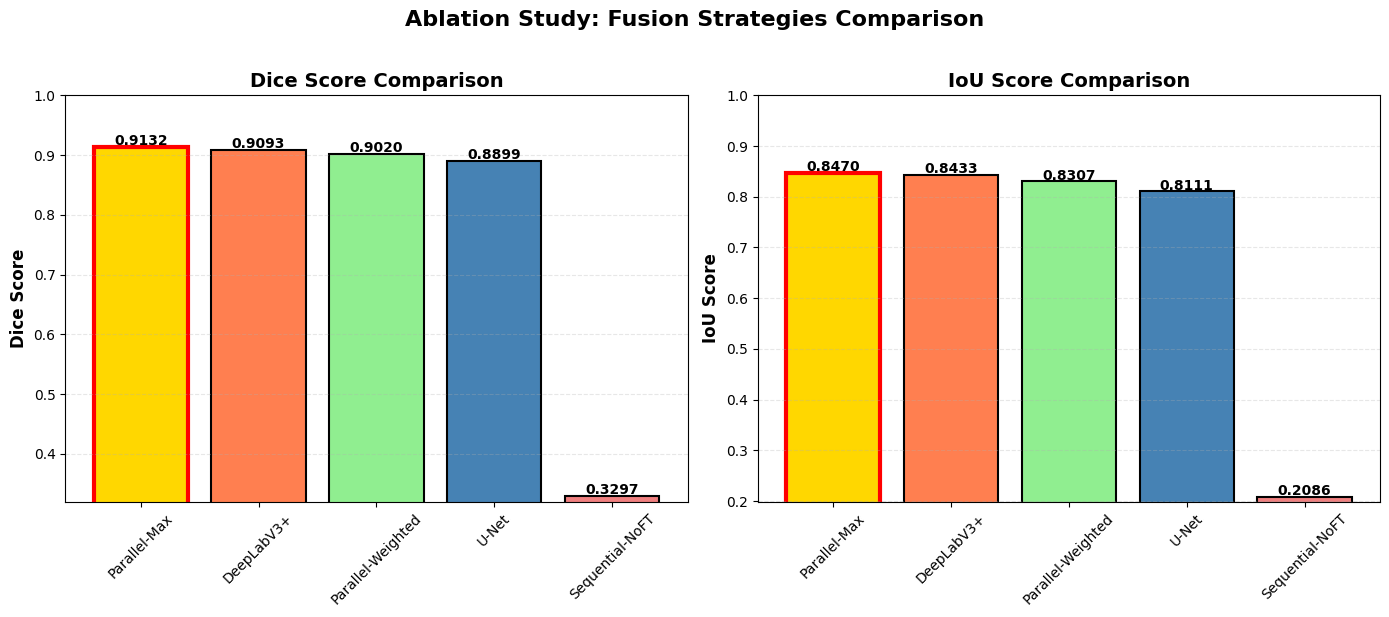

✅ Saved visualization:  d:/DoAn_DaLieu/5_Results/ablation_fusion_strategies.png


In [ ]:
# ==============================================================================
# Ô CODE 11: VISUALIZATION (Trực quan hóa)
# ==============================================================================
print("\n" + "="*80)
print("📊 CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = df_results['Method'].tolist()
dice_vals = df_results['Dice'].tolist()
iou_vals = df_results['IoU'].tolist()

# Color coding (Mã màu)
colors = []
for method in methods:
    if 'U-Net' in method and 'Parallel' not in method:
        colors.append('steelblue')
    elif 'DeepLab' in method and 'Parallel' not in method:
        colors.append('coral')
    elif 'Parallel-Max' in method:
        colors.append('gold')  # Highlight best (Làm nổi bật tốt nhất)
    elif 'Parallel-Weighted' in method:
        colors.append('lightgreen')
    else:  # Sequential
        colors.append('lightcoral')

# Plot 1: Dice scores
bars1 = axes[0].bar(methods, dice_vals, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
axes[0].set_title('Dice Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([min(dice_vals) - 0.01, 1.0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Highlight best method (Đánh dấu phương pháp tốt nhất)
best_idx = dice_vals.index(max(dice_vals))
bars1[best_idx].set_edgecolor('red')
bars1[best_idx].set_linewidth(3)

# Annotate values (Ghi chú giá trị)
for i, v in enumerate(dice_vals):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

# Plot 2: IoU scores
bars2 = axes[1].bar(methods, iou_vals, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('IoU Score', fontsize=12, fontweight='bold')
axes[1].set_title('IoU Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([min(iou_vals) - 0.01, 1.0])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Highlight best (Đánh dấu tốt nhất)
best_iou_idx = iou_vals.index(max(iou_vals))
bars2[best_iou_idx].set_edgecolor('red')
bars2[best_iou_idx].set_linewidth(3)

# Annotate
for i, v in enumerate(iou_vals):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Ablation Study: Fusion Strategies Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure (Lưu hình)
save_path = os.path.join(GDRIVE_PATH, "5_Results", "ablation_fusion_strategies.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved visualization:  {save_path}")

In [ ]:
# ==============================================================================
# Ô CODE 12: SAVE RESULTS (Lưu kết quả)
# ==============================================================================
print("\n" + "="*80)
print("💾 SAVING RESULTS")
print("="*80)

# Save to CSV (Lưu vào CSV)
csv_path = os.path.join(GDRIVE_PATH, "5_Results", "ablation_fusion_results.csv")
df_results.to_csv(csv_path, index=False)
print(f"✅ Saved CSV: {csv_path}")

# Save to JSON (Lưu vào JSON)
json_results = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'best_method': best_method,
    'best_dice': float(best_dice),
    'results': {
        k: {'dice': float(v['dice']), 'iou': float(v['iou'])}
        for k, v in results.items()
    },
    'statistical_test': {
        'comparison': 'Parallel-Max vs Sequential-NoFT',
        'p_value': float(p_value),
        'significant': bool(p_value < 0.05)
    }
}

json_path = os.path.join(GDRIVE_PATH, "5_Results", "ablation_fusion_results.json")
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=4)
print(f"✅ Saved JSON: {json_path}")

print("\n" + "="*80)
print("✅ ABLATION STUDY COMPLETE!")
print("="*80)
print(f"\n🏆 Winner: {best_method}")
print(f"📊 Dice:  {best_dice:.4f}")
print(f"💡 Parallel-Max is {'SIGNIFICANTLY' if p_value < 0.05 else 'NOT significantly'} better than Sequential (no FT)")


💾 SAVING RESULTS
✅ Saved CSV: d:/DoAn_DaLieu/5_Results/ablation_fusion_results.csv
✅ Saved JSON: d:/DoAn_DaLieu/5_Results/ablation_fusion_results.json

✅ ABLATION STUDY COMPLETE!

🏆 Winner: Parallel-Max
📊 Dice:  0.9132
💡 Parallel-Max is SIGNIFICANTLY better than Sequential (no FT)
